<a href="https://colab.research.google.com/github/MGhennam/100-days-of-code-python/blob/main/Copie_de_Untitled10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aperçu des données :
        B02       B04       B08       B11      NDVI  Pollution_Target
0  0.106181  0.087027  0.178512  0.218176  0.414796          0.244883
1  0.192607  0.158380  0.174094  0.249170  0.624889          0.339366
2  0.159799  0.224589  0.371876  0.112617  0.584145          0.208841
3  0.139799  0.196445  0.174864  0.206219  0.038510          0.376106
4  0.073403  0.211312  0.181585  0.192936  0.034325          0.262965

Évaluation du modèle :
Mean Squared Error: 0.0003
R² Score: 0.9641


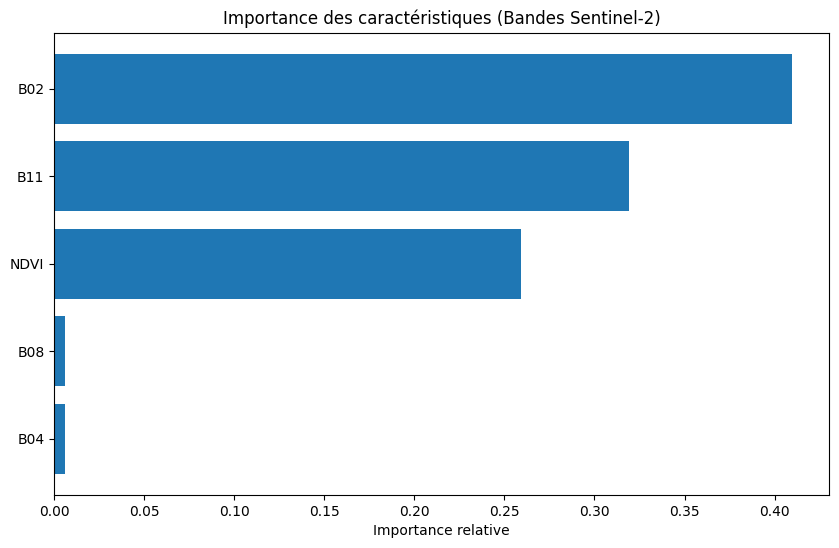

In [ ]:
# 1. Importation des bibliothèques
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 2. Simulation de chargement des données Sentinel-2 et Labels (Station sol)
# En situation réelle, utilisez rasterio.open('chemin_image.tif')
def load_and_preprocess_data():
    # Caractéristiques (Features) : Bandes B2 (Bleu), B4 (Rouge), B8 (NIR), B11 (SWIR)
    # Imaginons un dataset de 1000 points d'échantillonnage
    np.random.seed(42)
    n_samples = 1000

    data = {
        'B02': np.random.uniform(0.05, 0.2, n_samples),
        'B04': np.random.uniform(0.05, 0.25, n_samples),
        'B08': np.random.uniform(0.1, 0.4, n_samples),
        'B11': np.random.uniform(0.05, 0.3, n_samples),
        'NDVI': np.random.uniform(-0.1, 0.8, n_samples) # Index calculé (B8-B4)/(B8+B4)
    }

    df = pd.DataFrame(data)

    # Variable cible (Target) : Concentration de pollution (ex: PM2.5 ou AOD)
    # Création d'une relation synthétique pour l'exemple
    df['Pollution_Target'] = (df['B02'] * 1.5) + (df['B11'] * 0.8) - (df['NDVI'] * 0.2) + np.random.normal(0, 0.01, n_samples)

    return df

df = load_and_preprocess_data()
print("Aperçu des données :")
print(df.head())

# 3. Préparation du modèle
X = df.drop('Pollution_Target', axis=1)
y = df['Pollution_Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Entraînement du modèle (Random Forest)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Évaluation
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nÉvaluation du modèle :")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# 6. Visualisation de l'importance des bandes (Features Importance)
plt.figure(figsize=(10, 6))
importances = model.feature_importances_
indices = np.argsort(importances)
plt.title('Importance des caractéristiques (Bandes Sentinel-2)')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Importance relative')
plt.show()

# 7. Prédiction sur une image complète (Inférence)
# Note : Pour appliquer le modèle à une image entière (.tif)
def predict_on_raster(model, input_path, output_path):
    with rasterio.open(input_path) as src:
        # Lecture des bandes nécessaires
        profile = src.profile
        img = src.read([2, 4, 8, 11]) # Exemple : Lecture des bandes B2, B4, B8, B11

        # Reshape pour le modèle (Pixels, Features)
        c, h, w = img.shape
        img_reshaped = img.reshape(c, h * w).T

        # Prédiction
        prediction = model.predict(img_reshaped)
        prediction_map = prediction.reshape(h, w)

        # Sauvegarde du résultat
        profile.update(dtype=rasterio.float32, count=1)
        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(prediction_map.astype(rasterio.float32), 1)
    print(f"Carte de pollution générée : {output_path}")

# predict_on_raster(model, 'S2_Image.tif', 'Pollution_Map.tif')


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Simulation de données (Remplacez par vos extractions Sentinel-2)
def generate_satellite_data(n=2000):
    np.random.seed(42)
    # Bandes : B2, B3, B4, B8, B11, B12 + NDVI
    X = np.random.rand(n, 7)
    # Cible : Concentration de polluant avec une relation non-linéaire complexe
    y = (np.sin(X[:, 0] * 5) + (X[:, 4]**2) - (X[:, 6] * 0.5)) + np.random.normal(0, 0.05, n)
    return X, y

X, y = generate_satellite_data()

# Normalisation (Crucial pour le Deep Learning)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2)


In [ ]:
def build_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2), # Prévention du surapprentissage
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1) # Sortie unique pour la régression (concentration)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_model(X_train.shape[1])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.7596 - mae: 0.7289 - val_loss: 0.5317 - val_mae: 0.6182
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4097 - mae: 0.5385 - val_loss: 0.2410 - val_mae: 0.4042
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2313 - mae: 0.3938 - val_loss: 0.1404 - val_mae: 0.3022
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1864 - mae: 0.3505 - val_loss: 0.1099 - val_mae: 0.2673
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1561 - mae: 0.3170 - val_loss: 0.0938 - val_mae: 0.2442
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1328 - mae: 0.2924 - val_loss: 0.0802 - val_mae: 0.2262
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1264 - mae: 0.2822 - val_loss: 0.0698 - val_mae: 0.2079
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1021 - mae: 0.2549 - val_loss: 0.0620 - val_mae: 0.1951
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.104

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


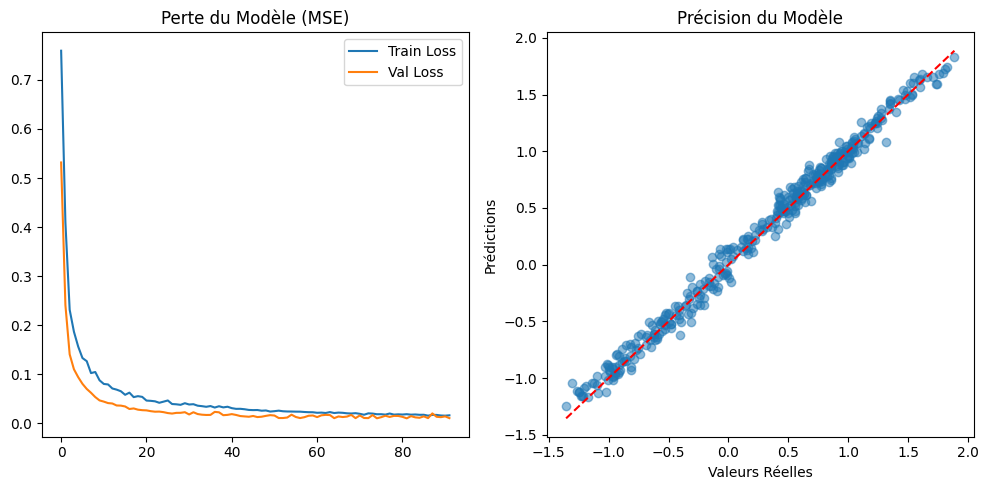

In [ ]:
# Prédictions
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_actual = scaler_y.inverse_transform(y_test)

# Graphique de performance
plt.figure(figsize=(10, 5))

# Sous-graphique 1 : Courbe d'apprentissage
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Perte du Modèle (MSE)')
plt.legend()

# Sous-graphique 2 : Corrélation
plt.subplot(1, 2, 2)
plt.scatter(y_actual, y_pred, alpha=0.5)
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--')
plt.xlabel('Valeurs Réelles')
plt.ylabel('Prédictions')
plt.title('Précision du Modèle')

plt.tight_layout()
plt.show()

In [ ]:
import rasterio
import numpy as np

def align_dem_to_sentinel(sentinel_path, dem_path):
    with rasterio.open(sentinel_path) as s2:
        meta = s2.meta
        upscale_factor = 1/3 # Si DEM est à 30m et S2 à 10m

        with rasterio.open(dem_path) as dem:
            # Resampling du DEM pour correspondre à la grille 10m de Sentinel-2
            dem_data = dem.read(
                1,
                out_shape=(s2.height, s2.width),
                resampling=rasterio.Enums.Resampling.bilinear
            )
    return dem_data

# dem_alger_10m = align_dem_to_sentinel('S2_Alger_B02.tif', 'SRTM_Alger.tif')

In [ ]:
from tensorflow.keras import layers, models

def build_alger_cnn(input_shape):
    model = models.Sequential([
        # Entrée : Patch d'image de 32x32 pixels autour d'un point
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='linear') # Concentration de NO2 ou PM2.5
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# Modèle pour des patches de 32x32 avec 4 canaux (B2, B4, B8, NDVI)
# model = build_alger_cnn((32, 32, 4))


In [ ]:
import rasterio
import numpy as np

def align_dem_to_sentinel(sentinel_path, dem_path):
    with rasterio.open(sentinel_path) as s2:
        meta = s2.meta
        upscale_factor = 1/3 # Si DEM est à 30m et S2 à 10m

        with rasterio.open(dem_path) as dem:
            # Resampling du DEM pour correspondre à la grille 10m de Sentinel-2
            dem_data = dem.read(
                1,
                out_shape=(s2.height, s2.width),
                resampling=rasterio.Enums.Resampling.bilinear
            )
    return dem_data

# dem_alger_10m = align_dem_to_sentinel('S2_Alger_B02.tif', 'SRTM_Alger.tif')

In [ ]:
from tensorflow.keras import layers, models, Model

def build_alger_fusion_model(input_shape_spectral, input_shape_topo):
    # Branche 1 : Données Satellite (B2, B4, B8, B11)
    input_spectral = layers.Input(shape=(input_shape_spectral,))
    x = layers.Dense(64, activation='relu')(input_spectral)
    x = layers.Dense(32, activation='relu')(x)

    # Branche 2 : Données Topographiques (Altitude, Pente)
    input_topo = layers.Input(shape=(input_shape_topo,))
    y = layers.Dense(16, activation='relu')(input_topo)

    # Fusion des deux branches
    combined = layers.concatenate([x, y])

    # Couches finales
    z = layers.Dense(32, activation='relu')(combined)
    z = layers.Dense(16, activation='relu')(z)
    output = layers.Dense(1, activation='linear')(z)

    model = Model(inputs=[input_spectral, input_topo], outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Exemple : 6 bandes spectrales et 2 variables topo (altitude + pente)
# model = build_alger_fusion_model(6, 2)


In [ ]:
import numpy as np

def calculate_topo_features(dem_array, cell_size=10):
    """
    Calcule la pente et l'orientation à partir d'un tableau NumPy de MNT.
    cell_size : résolution de Sentinel-2 (10 mètres).
    """
    # Calcul des gradients (différences d'altitude)
    dz_dx, dz_dy = np.gradient(dem_array, cell_size)

    # 1. Calcul de la Pente (Slope) en degrés
    slope = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))
    slope_deg = np.rad2deg(slope)

    # 2. Calcul de l'Orientation (Aspect) en degrés
    # 0 = Nord, 90 = Est, 180 = Sud, 270 = Ouest
    aspect = np.arctan2(-dz_dy, dz_dx)
    aspect_deg = np.rad2deg(aspect)
    aspect_deg = (aspect_deg + 360) % 360

    return slope_deg, aspect_deg

# Utilisation
# slope, aspect = calculate_topo_features(dem_alger_10m)

In [ ]:
# Préparation des données pour le modèle de fusion précédent
def prepare_final_input(spectral_data, dem, slope, aspect):
    # On aplatit les matrices pour le modèle Dense ou on garde les patches pour CNN
    topo_features = np.stack([dem, slope, aspect], axis=-1)

    # Normalisation spécifique pour la topo
    # Altitude Alger : 0 à ~430m | Pente : 0 à ~45° | Aspect : 0 à 360°
    topo_features[..., 0] /= 450.0
    topo_features[..., 1] /= 90.0
    topo_features[..., 2] /= 360.0

    return topo_features

# topo_input = prepare_final_input(stack_alger, dem_alger_10m, slope, aspect)

In [ ]:
import matplotlib.pyplot as plt

def plot_alger_results(rgb_image, dem, slope, pollution_map):
    """
    Affiche la comparaison entre le terrain et la pollution.
    rgb_image : Image Sentinel-2 (B4, B3, B2) normalisée
    dem : MNT d'Alger
    slope : Pente calculée
    pollution_map : Résultat de l'inférence du modèle DL
    """
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

    # 1. Vue Satellite Réelle (Alger)
    axes[0].imshow(rgb_image)
    axes[0].set_title("1. Sentinel-2 RGB (Alger)")
    axes[0].axis('off')

    # 2. Topographie (Altitude)
    im2 = axes[1].imshow(dem, cmap='terrain')
    axes[1].set_title("2. Altitude (MNT)")
    plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    axes[1].axis('off')

    # 3. Pente (Analyse du relief)
    im3 = axes[2].imshow(slope, cmap='magma')
    axes[2].set_title("3. Pente (Slope)")
    plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
    axes[2].axis('off')

    # 4. Prédiction Pollution (Deep Learning)
    # On utilise 'jet' ou 'inferno' pour marquer les zones critiques
    im4 = axes[3].imshow(pollution_map, cmap='jet')
    axes[3].set_title("4. Pollution Prédite (DL)")
    plt.colorbar(im4, ax=axes[3], fraction=0.046, pad=0.04)
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

# Exemple d'appel (après inférence) :
# plot_alger_results(image_rgb, dem_alger_10m, slope_deg, prediction_2d)


In [ ]:
import rasterio

def export_prediction_to_geotiff(prediction_array, reference_path, output_path):
    """
    Sauvegarde la carte de pollution au format GeoTIFF.
    prediction_array : Matrice 2D issue du modèle Deep Learning
    reference_path : Chemin vers une image Sentinel-2 d'origine (pour copier les métadonnées)
    output_path : Nom du fichier de sortie
    """
    with rasterio.open(reference_path) as src:
        # Copie du profil (CRS, transform, dimensions) de l'image source
        profile = src.profile

        # Mise à jour du profil pour le fichier de sortie
        profile.update(
            dtype=rasterio.float32,
            count=1,          # Une seule bande (la pollution)
            compress='lzw'    # Compression sans perte pour réduire la taille
        )

        with rasterio.open(output_path, 'w', **profile) as dst:
            # Écriture de la matrice de prédiction
            # Note : On s'assure que le type de données est float32
            dst.write(prediction_array.astype(rasterio.float32), 1)

    print(f"✅ Exportation réussie : {output_path}")

# Exemple d'utilisation :
# export_prediction_to_geotiff(pollution_pred, 'S2_Alger_B02.tif', 'Pollution_Alger_Final.tif')